# Installation

In [ ]:
pip install devito

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.9/132.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 7.9 MB/s eta 0:00:00
  Created wheel for cgen: filename=cgen-2025.1-py3-none-any.whl size=19883 sha256=7d2b102c1ef0b7ece7a87b14a9a7dd771731ce0432ae44284f76f722e027954e
  Stored in directory: /root/.cache/pip/wheels/50/1a/02/97f23c102994cf34e52e405bc2e2889aaf463fdcb37d23ca3a
  Created wheel for codepy: filename=codepy-2023.1-py3-none-any.whl size=24869 sha256=19e4bcf9b99be4e9e1a8858bb34567051dd9b47de16e46e74be97bbfc65cffc1
  Stored in directory: 

# Definições

In [ ]:
#------------------- Bibliotecas utilizadas --------------------------
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt
from IPython.display import display, Math, Latex

import time
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

from devito import Grid, Function, TimeFunction, Operator, configuration, Eq, solve, Constant
from sympy import nsimplify, pprint
from devito.logger import warning
from examples.cfd import plot_field, init_hat

In [ ]:
def plot3D(X, Y, w_ex, f):
    fig = plt.figure(figsize=(7, 7), dpi=100)
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, f[:].T, rstride=1, cstride=1, cmap="viridis",
            linewidth=0, antialiased=False)
    ax.scatter3D(X, Y, w_ex, color = "red", label = 'Solução Numerica');              #Pontos da Solucao Analitica
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    plt.savefig('Figura Solucao 3d.png', transparent=True, dpi=300);
    files.download('Figura Solucao 3d.png') #fazendo download do arquivo gerado no google colab
    plt.show()

def plot_3d_comparison(x, y, numerical_solution, analytical_solution):
    """
    Plota comparação 3D entre solução numérica (superfície) e analítica (pontos)

    Parâmetros:
    x : array 1D - coordenadas x da malha
    y : array 1D - coordenadas y da malha
    numerical_solution : array 2D - solução numérica em toda a malha
    analytical_solution : array 2D - solução analítica em toda a malha
    """
    # Cria malha para plotagem 3D
    X, Y = np.meshgrid(x, y, indexing='ij')

    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plota superfície da solução numérica
    surf = ax.plot_surface(X, Y, analytical_solution.T,
                          cmap='viridis', alpha=0.7,
                          label='Solução Analítica')

    # Plota pontos da solução analítica (mostrando 1 a cada 2 pontos para melhor visualização)
    scatter = ax.scatter(X[::2,::2], Y[::2,::2], numerical_solution.T[::2,::2],
                        color='red', s=50, depthshade=True,
                        label='Solução Numérica')

    # Configurações do gráfico
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_zlabel(r'p(x,y,z)', fontsize=12)
    #ax.set_title('Comparação 3D: Solução Numérica vs Analítica', fontsize=14)

    # Criando legendas manualmente
    surf._edgecolors2d = surf._edgecolor3d  # Correção para legendas 3D
    surf._facecolors2d = surf._facecolor3d
    ax.legend()

    # Ajusta a visualização
    ax.view_init(elev=30, azim=45)
    plt.tight_layout()
    plt.show()

# Equação de Poisson

$$ \dfrac{\partial ^2 p}{\partial x^2} + \dfrac{\partial ^2 p}{\partial y^2} + \dfrac{\partial ^2 p}{\partial z^2} = 2\left[ (y^2-y)(z^2-z) + (x^2-x)(z^2-z) + (x^2-x)(y^2-y)\right]$$

c.c. Dirichlet; $[0,1]$x$[0,1]$x$[0,1]$

# Devito

In [ ]:
nx = 16
ny = nx
nz = nx
xmin, xmax = 0., 1.
ymin, ymax = 0., 1.
zmin, zmax = 0., 1.

compx = xmax - xmin
compy = ymax - ymin
compz = zmax - zmin

dx = (compx) / (nx)
dy = (compy) / (ny)
dz = (compz) / (nz)

x_ = np.linspace(xmin, xmax, nx)
y_ = np.linspace(ymin, ymax, ny)
z_ = np.linspace(zmin, zmax, nz)

X, Y, Z = np.meshgrid(x_,y_,z_,indexing='ij')

sigma = 0.1
dt = (sigma * dx * dy * dz)
tstop = 1
nt = round(tstop / dt)

Grid[extent=(np.float32(1.0), np.float32(1.0), np.float32(1.0)), shape=(16, 16, 16), dimensions=(x, y, z)]
p(t, x, y, z)
CPU times: user 235 ms, sys: 2.02 ms, total: 237 ms
Wall time: 238 ms


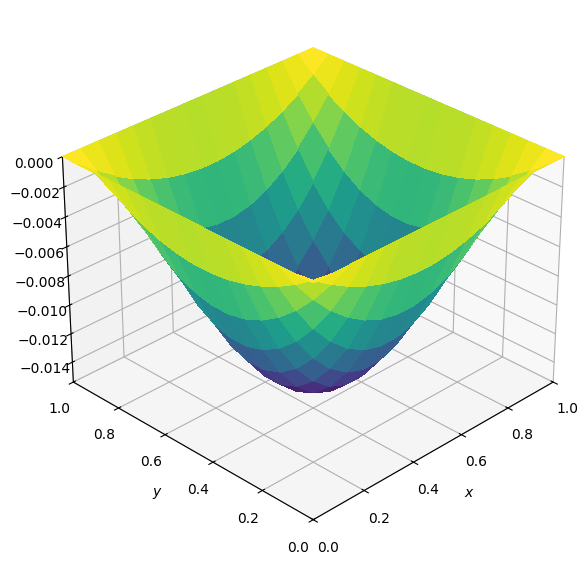

In [ ]:
# Silence the runtime performance logging
configuration['log-level'] = 'ERROR'

grid = Grid(shape=(nx, ny, nz), extent=(compx, compy, compz))
p = TimeFunction(name='p', grid=grid, space_order=2)
p.data[:] = 0.
x, y, z = grid.dimensions
t = grid.stepping_dim

f = Function(name='f', shape=(nx,ny,nz), dimensions=(x,y,z), grid = grid)
f_data = 2*((Y**2-Y)*(Z**2-Z) + (X**2-X)*(Z**2-Z) + (X**2-X)*(Y**2-Y))
f.data[:] = f_data.reshape((nx, ny, nz))

print(grid)
print(p)

eq = Eq(p.laplace, f)
stencil = solve(eq, p)
eq_stencil = Eq(p.forward, stencil)

# Boundary condition expressions
bc = [Eq(p[t+1, x, y, 0], 0.)]      # z
bc += [Eq(p[t+1, x, y, nz-1], 0.)]

bc += [Eq(p[t + 1, x, 0, z], 0.)]   # y
bc += [Eq(p[t + 1, x, ny-1,z], 0.)]

bc += [Eq(p[t + 1, 0, y,z], 0.)]    # x
bc += [Eq(p[t + 1, nx-1, y,z], 0.)]

configuration['log-level'] = 'ERROR'
# Create and execute the operator for a number of timesteps
op = Operator([eq_stencil] + bc)
%time op(time=nt)

# Select a 2D slice of the 3D result for plotting.
# We will plot the data at the middle z-index.
z_slice_index = nz // 2 # Integer division to get the middle index
p_slice = p.data[0, :, :, z_slice_index].view(np.ndarray)

plot_field(p_slice, xmin=xmin, ymin=ymin, xmax=xmax, ymax=ymax, view=(30,225))

In [ ]:
f_analytical = (X**2-X)*(Y**2-Y)*(Z**2-Z)
error = np.sqrt(np.sum((f_analytical - p.data)**2 )) / np.sqrt(np.sum((f_analytical)**2 ))
print(error)

6.821639478876028e-07


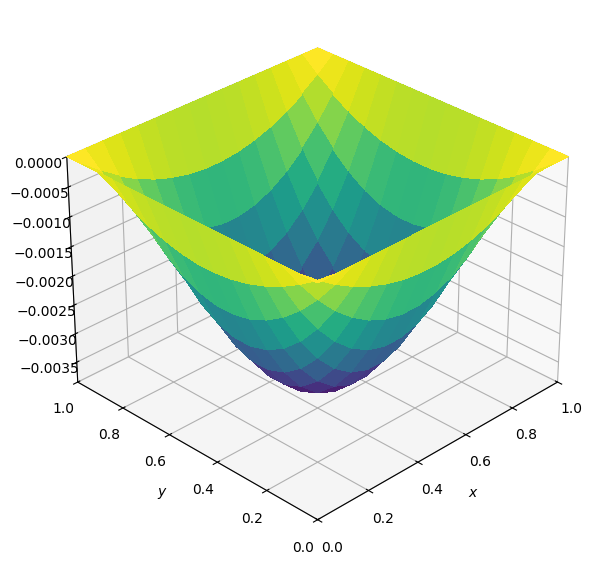

In [ ]:
plot_field(p.data[0, :, :, nz-2], xmin=xmin, ymin=ymin, xmax=xmax, ymax=ymax, view=(30,225))

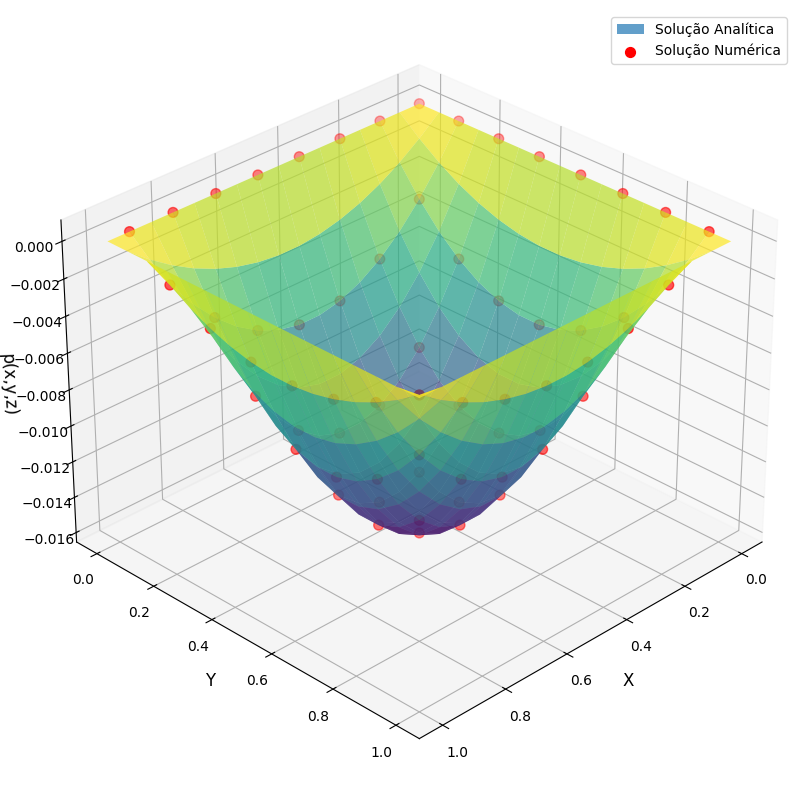

In [ ]:
# Plota a solução analítica como superfície e a numérica como pontos
plot_3d_comparison(x_.flatten(), y_.flatten(), p.data[0, :, :, z_slice_index], f_analytical[:, :, z_slice_index])

In [ ]:
import plotly.graph_objects as go
import numpy as np

# Assuming p.data[0] contains your 3D solution data
solution_data = p.data[0]

# Create coordinates in [0,1] range
x_coords = np.linspace(0, 1, nx)
y_coords = np.linspace(0, 1, ny)
z_coords = np.linspace(0, 1, nz)

# Create meshgrid for volume coordinates
X, Y, Z = np.meshgrid(x_coords, y_coords, z_coords, indexing='ij')

# Convert solution_data to a NumPy array for calculations
solution_data_np = np.asarray(solution_data)

fig = go.Figure(data=go.Volume(
    x=X.flatten(),  # X coordinates in [0,1]
    y=Y.flatten(),  # Y coordinates in [0,1]
    z=Z.flatten(),  # Z coordinates in [0,1]
    value=solution_data.flatten(),
    isomin=solution_data_np.min() + 0.1*(solution_data_np.max()-solution_data_np.min()),
    isomax=solution_data_np.min() + 0.9*(solution_data_np.max()-solution_data_np.min()),
    opacity=0.1,    # Lower opacity makes it easier to see through
    surface_count=15,  # Number of isosurfaces to show
    colorscale='Viridis',  # Color scale
    caps=dict(x_show=False, y_show=False, z_show=False)  # Remove caps for better view
))

# Adjust the layout to show proper [0,1] axes
fig.update_layout(
    title='3D Solution',
    scene=dict(
        xaxis=dict(range=[0, 1], title='X'),
        yaxis=dict(range=[0, 1], title='Y'),
        zaxis=dict(range=[0, 1], title='Z'),
        aspectmode='cube'  # Ensures equal aspect ratio
    ),
    width=1000,
    height=800,
    margin=dict(r=20, l=10, b=10, t=30)
)

fig.show()